# The fair comparison

**Week 1, Thursday. Chapter 6 of 6, the afternoon.** By the end of this notebook you can ask the
three questions every campaign readout needs (who got it, who did not, what else changed), see why
a before-and-after number misleads, reach the verdict a second way, and design the comparison that
would settle it at Diwali.

> **The client asks.** "Diwali is five weeks away. I want the monsoon sale again, and I want it for
> more of the base."
>
> The marketing lead, Kalpa Retail, answering the morning's note

**The metric at stake.** Revenue from the targeted segment in the sale month, and the question
under it: what would these customers have spent without the sale? **Who asks and what rides on
it.** The marketing lead wants the Diwali budget; Meera needs to know whether a sale at 15 percent
off makes money or gives margin to customers who would have bought anyway. **Who else faces it.**
eBay stopped buying search ads on its own brand name in a controlled test and found that almost
all of the lost clicks arrived through ordinary search results instead; the researchers reported
that those ads had no measurable short-term benefit, and that the frequent buyers who saw most of
eBay's other search ads would have bought anyway, which made the average return negative.

Chapter 4 split the blend by segment and chapter 5 wrote the note. This chapter adds
`month_delivered` and `month_orders`, and opens the orders file by month.

**Setup.** The whole toolkit, plus the two month helpers.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

import random
import time

ORDERS = kit.load_csv("C2_W01_D04_orders_STUDENT.csv")
SEGMENTS = ["Retail-Core", "Retail-Plus", "Student", "Business"]


def mean(values):
    return sum(values) / len(values)


def member_totals(segment, quarter):
    """Delivered revenue per member of one segment in one quarter, one number per member."""
    members = sorted({o["customer_id"] for o in ORDERS if o["segment"] == segment})
    totals = {m: 0 for m in members}
    for o in ORDERS:
        if o["segment"] == segment and o["quarter"] == quarter and o["status"] == "delivered":
            totals[o["customer_id"]] += int(o["amount"])
    return [totals[m] for m in members]


def shuffle_gaps(q1, q2, times, seed):
    """Deal the pooled values to two piles at random, many times, and keep each gap."""
    random.seed(seed)                  # the same shuffles on every laptop
    pool = q1 + q2                     # all the cards, labels ignored
    gaps = []
    for _ in range(times):
        random.shuffle(pool)           # deal at random
        gaps.append(mean(pool[:len(q1)]) - mean(pool[len(q1):]))
    return gaps


def share_at_least(gaps, real):
    """The share of chance-only worlds whose gap is at least as large as the real one."""
    return sum(1 for g in gaps if g >= real) / len(gaps)


def delivered(segment, quarter):
    """A segment's delivered revenue in one quarter, in rupees."""
    return sum(int(o["amount"]) for o in ORDERS
               if o["segment"] == segment and o["quarter"] == quarter and o["status"] == "delivered")


def bootstrap_gaps(q1, q2, times, seed):
    """Redraw each quarter's members with replacement, many times, and keep each gap."""
    random.seed(seed)
    return [mean([random.choice(q1) for _ in q1]) - mean([random.choice(q2) for _ in q2])
            for _ in range(times)]


def orders_in(segment, quarter):
    return sum(1 for o in ORDERS if o["segment"] == segment and o["quarter"] == quarter)


def flip_rises(n_orders, times, seed):
    """Deal each of n orders to Q1 or Q2 by a fair coin, many times, and keep each rise."""
    random.seed(seed)
    rises = []
    for _ in range(times):
        q2 = sum(1 for _ in range(n_orders) if random.random() < 0.5)
        q1 = n_orders - q2
        rises.append(float("inf") if q1 == 0 else q2 / q1 - 1)
    return rises


EXPOSURE = kit.load_csv("C2_W01_D04_exposure_STUDENT.csv")
CAMPAIGNS = kit.load_csv("C2_W01_D04_campaigns_STUDENT.csv")


def spend(rows):
    """August revenue per customer across a list of exposure rows."""
    return mean([int(r["august_revenue"]) for r in rows])


def group(flag, segment=None):
    """The exposure rows for one group, exposed "yes" or "no", optionally inside one segment."""
    return [r for r in EXPOSURE if r["exposed"] == flag and (segment is None or r["segment"] == segment)]


def month_delivered(segment, month):
    """A segment's delivered revenue in one calendar month, month as "2026-08"."""
    return sum(int(o["amount"]) for o in ORDERS if o["segment"] == segment
               and o["order_date"][:7] == month and o["status"] == "delivered")


def month_orders(segment, month):
    return [o for o in ORDERS if o["segment"] == segment and o["order_date"][:7] == month
            and o["status"] == "delivered"]

MONTHS = ["2026-04", "2026-05", "2026-06", "2026-07", "2026-08", "2026-09"]
print("orders by month ready for", len(MONTHS), "months; the sale ran", CAMPAIGNS[0]["starts"], "to", CAMPAIGNS[0]["ends"])

orders by month ready for 6 months; the sale ran 2026-08-05 to 2026-08-19


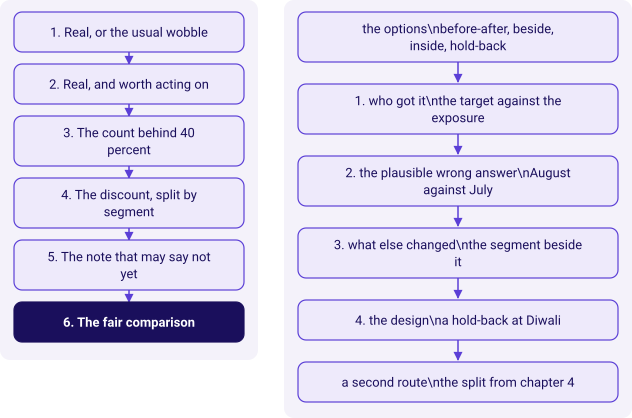

In [2]:
kit.side_by_side(
    kit.ladder(['Real, or the usual wobble', 'Real, and worth acting on', 'The count behind 40 percent', 'The discount, split by segment', 'The note that may say not yet', 'The fair comparison'], lit=5, show=False),
    kit.vflow(['the options\\nbefore-after, beside, inside, hold-back', '1. who got it\\nthe target against the exposure', '2. the plausible wrong answer\\nAugust against July', '3. what else changed\\nthe segment beside it', '4. the design\\na hold-back at Diwali', 'a second route\\nthe split from chapter 4'], show=False),
)

## The options

Four ways a team could answer "did the sale cause the lift?"

| Option | What it compares | What it assumes |
|---|---|---|
| A. Before and after | The targeted segment in August against July | Nothing else changed between the months |
| B. The change beside the change | The targeted segment's move against an untargeted segment's move over the same months | Both segments would have moved alike without the sale |
| C. Inside each segment | Customers who got it against customers who did not, in the same month (chapter 4) | Who got it inside a segment was as good as random |
| D. A random hold-back | A coin decides, before the sale, which customers do not get it | Nothing, which is why it costs a campaign cycle |

Option,What it stands on,What it risks
A. Before and after,13 delivered orders,"the season, the tier's own drift"
B. Beside an untargeted segment,31 delivered orders,that the two segments move alike
C. Inside each segment,160 customers,"who got it was chosen, never random"
D. Random hold-back at Diwali,a fifth of 70 Retail-Plus customers,"about Rs 4,200 forgone if Marketing's 6 percent were real"


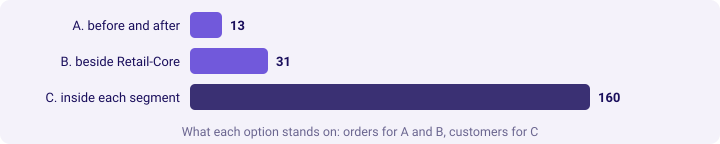

In [3]:
plus_jul, plus_aug = month_orders("Retail-Plus", "2026-07"), month_orders("Retail-Plus", "2026-08")
core_jul, core_aug = month_orders("Retail-Core", "2026-07"), month_orders("Retail-Core", "2026-08")
rp_customers = len(group("yes", "Retail-Plus")) + len(group("no", "Retail-Plus"))
held_back = rp_customers // 5
forgone = round(held_back * spend(group("no", "Retail-Plus")) * 0.06)
rows = [
    ("A. Before and after", f"{len(plus_jul) + len(plus_aug)} delivered orders", "the season, the tier's own drift"),
    ("B. Beside an untargeted segment", f"{len(plus_jul) + len(plus_aug) + len(core_jul) + len(core_aug)} delivered orders", "that the two segments move alike"),
    ("C. Inside each segment", f"{len(EXPOSURE)} customers", "who got it was chosen, never random"),
    ("D. Random hold-back at Diwali", f"a fifth of {rp_customers} Retail-Plus customers", f"about {kit.rupees(forgone)} forgone if Marketing's 6 percent were real"),
]
kit.table(["Option", "What it stands on", "What it risks"], rows, caption="The options sized on Kalpa's files")
kit.bars([("A. before and after", len(plus_jul) + len(plus_aug)),
          ("B. beside Retail-Core", len(plus_jul) + len(plus_aug) + len(core_jul) + len(core_aug)),
          ("C. inside each segment", len(EXPOSURE))], lit=[2],
         title="What each option stands on: orders for A and B, customers for C")
kit.check("before and after stands on fewer than thirty orders", len(plus_jul) + len(plus_aug) < 30)

**The best-fit call: D for Diwali, with C as today's best evidence.** A and B stand on a handful of
orders a month, and chapter 3 already said what a handful is worth. C is the fairest comparison the
files hold, and it still assumes who got the sale was as good as random inside each segment. D is
the only option where a coin decides, and its cost is small: if Marketing's 6 percent were real,
holding back a fifth of Retail-Plus forgoes a few thousand rupees. **The fact that would change the
call.** A campaign so large, or a hold-back so politically hard, that the forgone lift runs into
lakhs: then B, on a longer run of months, becomes the working answer with its caveat said aloud.

## 1. Who got it

The campaigns table says who the sale was aimed at; the exposure table says who received it.

**Predict before you run.** Of the customers who got the monsoon sale, the share who are
Retail-Plus members is: a) all of them, since it targeted Retail-Plus; b) about half; c) about a
tenth; d) none.

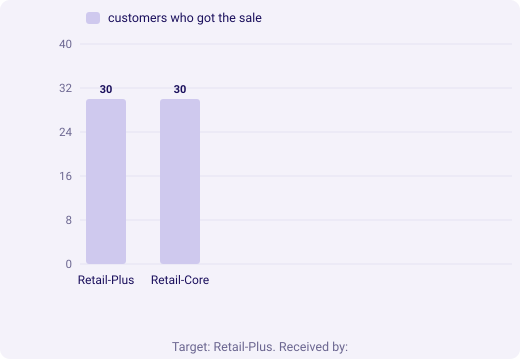

target Retail-Plus; received by {'Retail-Plus': 30, 'Retail-Core': 30}


In [4]:
got = {s: len(group("yes", s)) for s in ["Retail-Plus", "Retail-Core"]}
kit.columns(list(got), [("customers who got the sale", list(got.values()))], width=520,
            title=f"Target: {CAMPAIGNS[0]['target_segment']}. Received by:")
print(f"target {CAMPAIGNS[0]['target_segment']}; received by {got}")
kit.check("the sale reached customers outside its target segment", got["Retail-Core"] > 0, f"{got}")
kit.check("the exposure table covers both segments' customers", sum(got.values()) == len(group("yes")))

**What happened.** The answer is b. The sale was aimed at Retail-Plus and half of the customers who
got it were Retail-Core. Whatever rule chose them, it was a rule, never a coin, and a rule can pick
the customers who were going to buy anyway. That is the first of the three questions, and it is
already an answer: the groups were chosen.

## 2. The plausible wrong answer

**The plausible wrong answer.** A hurried readout opens the orders file and compares Retail-Plus in
the sale month with the month before.

In [5]:
rp_jul, rp_aug = month_delivered("Retail-Plus", "2026-07"), month_delivered("Retail-Plus", "2026-08")
before_after = rp_aug / rp_jul - 1
draft = (f"Retail-Plus delivered {kit.rupees(rp_aug)} in August against {kit.rupees(rp_jul)} in July, "
         f"up {before_after:.0%}: the monsoon sale worked, so run it for more of the base at Diwali.")
print(draft)

Retail-Plus delivered Rs 25,060 in August against Rs 9,280 in July, up 170%: the monsoon sale worked, so run it for more of the base at Diwali.


**Why it is wrong.** A before-and-after number credits the sale with everything else that happened
between July and August, and it stands on a handful of orders. If the draft wins, Diwali's sale is
widened on a jump that may belong to the month. **The check** asks what else changed: put the
untargeted segment beside it over the same months, and count what each month stands on.

## 3. What else changed

**Predict before you run.** Between July and August, Retail-Core's delivered revenue: a) fell, as
the sale pulled buyers to Retail-Plus; b) stayed flat; c) rose by a large share as well; d) cannot
be compared.

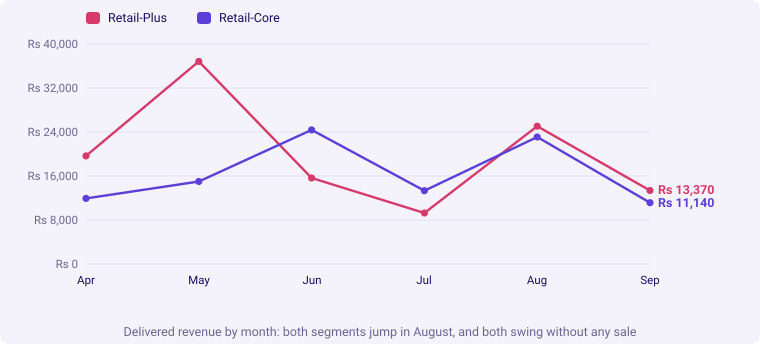

Segment,July,August,Change,"Delivered orders, July / August"
Retail-Plus,"Rs 9,280","Rs 25,060",+170%,4 / 9
Retail-Core,"Rs 13,320","Rs 23,090",+73%,6 / 12


Retail-Plus May to June, no sale running: -58%


In [6]:
rp = [month_delivered("Retail-Plus", m) for m in MONTHS]
core = [month_delivered("Retail-Core", m) for m in MONTHS]
kit.line(["Apr", "May", "Jun", "Jul", "Aug", "Sep"], [("Retail-Plus", rp, "bad"), ("Retail-Core", core, "plain")],
         fmt=kit.rupees, title="Delivered revenue by month: both segments jump in August, and both swing without any sale")
core_jump = core[4] / core[3] - 1
may_june = rp[2] / rp[1] - 1
kit.table(["Segment", "July", "August", "Change", "Delivered orders, July / August"],
          [("Retail-Plus", kit.rupees(rp[3]), kit.rupees(rp[4]), f"{before_after:+.0%}", f"{len(plus_jul)} / {len(plus_aug)}"),
           ("Retail-Core", kit.rupees(core[3]), kit.rupees(core[4]), f"{core_jump:+.0%}", f"{len(core_jul)} / {len(core_aug)}")],
          caption="July against August, with the orders behind each month")
print(f"Retail-Plus May to June, no sale running: {may_june:+.0%}")
kit.check("the untargeted segment also jumped in August", core_jump > 0.5, f"{core_jump:+.0%}")
kit.check("Retail-Plus swung by more than half between two months with no sale", abs(may_june) > 0.5, f"{may_june:+.0%}")
kit.check("July's Retail-Plus figure stands on fewer than ten orders", len(plus_jul) < 10, f"{len(plus_jul)}")

**What happened.** The answer is c. Retail-Core rose 73 percent from July to August with no sale
aimed at it, and Retail-Plus fell 58 percent from May to June with no sale at all. A month's revenue
on a few orders swings by half on its own, and August was a big month for both segments.

**The fix.** Compare like with like in time as well: take August's share of each segment's
quarter, and ask how often chance alone gives August that share of Retail-Plus's quarter, dealing
each of its delivered Q2 orders to a month at random.

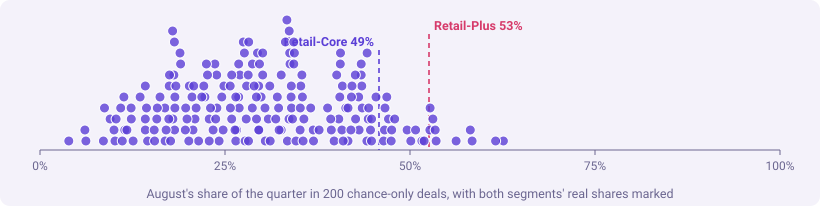

August's share of Q2: Retail-Plus 52.5%, Retail-Core 48.6%; chance gives Retail-Plus that share or more in 0.059 of deals


In [7]:
aug_share_rp = rp[4] / sum(rp[3:])
aug_share_core = core[4] / sum(core[3:])
amounts = [int(o["amount"]) for m in MONTHS[3:] for o in month_orders("Retail-Plus", m)]
random.seed(2026)
chance = []
for _ in range(5000):
    in_aug = sum(a for a in amounts if random.random() < 1 / 3)
    chance.append(in_aug / sum(amounts))
chance_share = sum(1 for c in chance if c >= aug_share_rp) / len(chance)
kit.strip(chance[:200], markers=[("Retail-Plus", aug_share_rp, "bad"), ("Retail-Core", aug_share_core, "plain")],
          lo=0, hi=1, fmt=lambda v: f"{v:.0%}", title="August's share of the quarter in 200 chance-only deals, with both segments' real shares marked")
print(f"August's share of Q2: Retail-Plus {aug_share_rp:.1%}, Retail-Core {aug_share_core:.1%}; "
      f"chance gives Retail-Plus that share or more in {chance_share:.3f} of deals")
kit.check("August's share is within a few points for the targeted and the untargeted segment",
          abs(aug_share_rp - aug_share_core) < 0.06, f"{aug_share_rp:.1%} against {aug_share_core:.1%}")
kit.check("chance gives Retail-Plus that August share in more than 1 deal in 20", chance_share > 0.05, f"{chance_share:.3f}")

What changed: the jump of 170 percent becomes an August that took 52 percent of Retail-Plus's
quarter against 49 percent of Retail-Core's, about four points apart, and chance alone gives
Retail-Plus's August a share that large in about 6 deals in 100. The month file cannot separate the
sale from a busy August.

## 4. The design: a hold-back at Diwali

The only comparison that answers "would they have bought anyway?" is one where a coin decides who
gets the sale. Decide before the sale, inside each segment, and agree the measure and the window in
advance.

**Predict before you run.** If Marketing's 6 percent were the true lift, holding back a random
fifth of the Retail-Plus customers in the comparison would forgo about: a) Rs 4,000; b) Rs 40,000;
c) Rs 4 lakh; d) nothing, since held-back customers still buy.

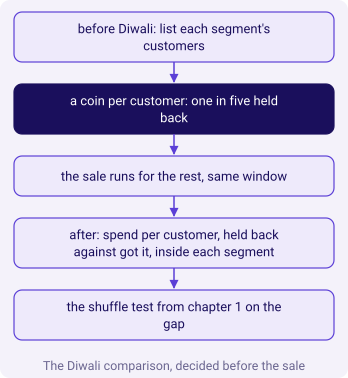

In [8]:
kit.vflow(["before Diwali: list each segment's customers",
           "a coin per customer: one in five held back",
           "the sale runs for the rest, same window",
           "after: spend per customer, held back against got it, inside each segment",
           "the shuffle test from chapter 1 on the gap"],
          lit=1, title="The Diwali comparison, decided before the sale")
kit.stats([(f"{held_back}", "held back", f"a fifth of {rp_customers} Retail-Plus customers"),
           (kit.rupees(forgone), "forgone", "if Marketing's 6 percent were real"),
           ("0", "rupees of discount", "given to the held-back customers")])
kit.check("the hold-back forgoes under Rs 10,000 even at Marketing's own lift", forgone < 10000, kit.rupees(forgone))

**What happened.** The answer is a. Fourteen held-back Retail-Plus customers at Rs 5,000 each and a 6
percent lift is about Rs 4,200, the whole price of knowing, and nothing if the lift is not real.

## A second route: the split from chapter 4

Chapter 4's comparison inside each segment used a different table and a different idea. Do the two
routes agree that the monsoon sale did not show a lift?

**Predict before you run.** a) yes, both find no lift the sale can claim; b) no, the months say it
worked; c) no, the split says it worked; d) they cannot be compared at all.

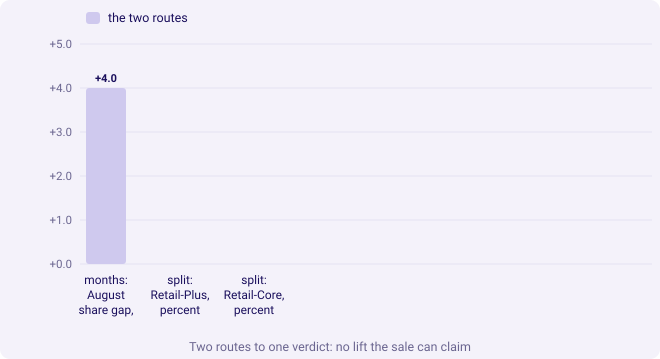

months: August took +4.0 points more of Retail-Plus's quarter than of Retail-Core's, and chance gives Retail-Plus that August share in about 6 deals in 100; split: Retail-Plus -3.0%, Retail-Core -3.0%


In [9]:
split = {s: spend(group("yes", s)) / spend(group("no", s)) - 1 for s in ["Retail-Plus", "Retail-Core"]}
month_gap = aug_share_rp - aug_share_core
kit.columns(["months: August share gap, points", "split: Retail-Plus, percent", "split: Retail-Core, percent"],
            [("the two routes", [round(100 * month_gap, 1), round(100 * split["Retail-Plus"], 1), round(100 * split["Retail-Core"], 1)])],
            fmt=lambda v: f"{v:+.1f}", width=660, title="Two routes to one verdict: no lift the sale can claim")
print(f"months: August took {100 * month_gap:+.1f} points more of Retail-Plus's quarter than of Retail-Core's, "
      f"and chance gives Retail-Plus that August share in about {round(chance_share * 100)} deals in 100; "
      f"split: " + ", ".join(f"{s} {v:+.1%}" for s, v in split.items()))
kit.check("the split finds the exposed spending less in both segments", all(v < 0 for v in split.values()))
kit.check("the months find no gap chance does not make", chance_share > 0.05)

**What happened.** The answer is a, with an honest difference. The months say "cannot tell": an
August share four points above the untargeted segment's, which chance gives Retail-Plus about 6
times in 100. The split says "3 percent less in both segments". Neither shows the lift Marketing claimed, and neither is a fair comparison, because
nobody tossed a coin. That is why the line to Meera stays "do not repeat it as designed" and the
action is the hold-back. **When to switch.** Use the change beside the change when months of data
exist and no hold-back was run; use the split when an exposure table exists; run the hold-back
whenever the next campaign can still be designed.

> **Kavya's review.** "Who got it: a rule, never a coin. Who did not: a different mix. What else
> changed: August, for everyone. Two routes find no lift, and you priced the test that would settle
> it at about Rs 4,200. Take that to Marketing as an offer, never as a verdict on their work."

### In the interview

**[F] Revenue rose after a discount; did the campaign work, and what would you need to know?** "Three
things: who got it, who did not, and what else changed. A before-and-after number credits the
campaign with the season. I would compare against customers who did not get it in the same window,
inside each segment, and I would ask for a random hold-back next time, because that is the only
comparison where the customers who would have bought anyway are in both groups."

**[F] How would you set up the Diwali campaign so you can tell whether it worked?** "Before the sale,
a coin per customer inside each segment holds back about one in five. Agree the measure and the
window in advance, run the sale for the rest, then compare spend per customer inside each segment
and test the gap against chance. At Marketing's own claimed lift the hold-back costs a few thousand
rupees, which is the price of knowing."

**[S] What is a confounder? Give an example from a campaign.** "Something that differs between the
groups and moves the outcome on its own. Here the sale went to a group with more high-spending
Retail-Plus members, and August was a big month for everyone, so both the mix and the month move
revenue whether or not the sale did anything."

**[D] Before and after, the change beside the change, the split, or a hold-back: which would you
defend to a CFO, and when would you settle for less?** "The hold-back, because only a coin removes
the customers who would have bought anyway from the comparison. I would settle for the change
beside the change on a long run of months when a hold-back is impossible, and say its assumption
aloud: that both segments would have moved alike."

### Depth: the change beside the change, named

Analysts call option B a difference in differences: the targeted segment's change less the
untargeted segment's change over the same window. Here it is in rupees, and why it cannot settle
this question.

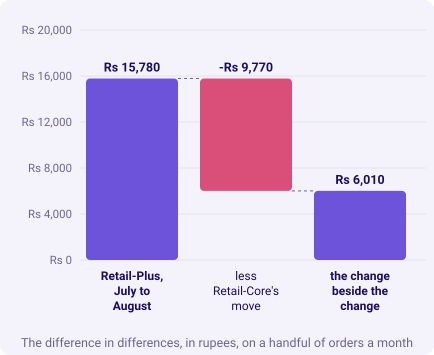

Retail-Plus moved Rs 15,780, Retail-Core Rs 9,770; difference Rs 6,010


In [10]:
did = (rp[4] - rp[3]) - (core[4] - core[3])
kit.bridge(("Retail-Plus, July to August", rp[4] - rp[3]), [("less Retail-Core's move", -(core[4] - core[3]))],
           end_label="the change beside the change", title="The difference in differences, in rupees, on a handful of orders a month")
print(f"Retail-Plus moved {kit.rupees(rp[4] - rp[3])}, Retail-Core {kit.rupees(core[4] - core[3])}; difference {kit.rupees(did)}")
kit.check("the difference rests on fewer than thirty orders in the targeted segment", len(plus_jul) + len(plus_aug) < 30)

It says Retail-Plus rose about Rs 6,000 more than Retail-Core, on 13 orders across the two months,
from a segment whose months swing by half with no sale running. That is a lead, never an answer,
and it points the same way as everything else in this chapter: run the hold-back.

In [11]:
kit.check_summary()
print("Next: the escalated case. Everything the six chapters built, alone, on all three questions.")

Next: the escalated case. Everything the six chapters built, alone, on all three questions.
